# Exercise 5

Check if installation was successfull.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import qiskit

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

%matplotlib inline

In [2]:
!{sys.executable} -m pip install pylatexenc

(a) Create and visualize the circuit from Exercise 4.

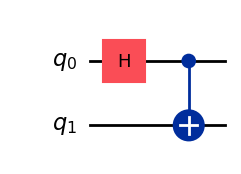

In [3]:
from qiskit import QuantumCircuit


# create a circuit with 2 qubits
circ = QuantumCircuit(2)

# TODO: apply the H-gate to the first qubit and the CNOT to both qubits

circ.h(0)
circ.cx(0,1)

# TODO: draw the circuit with matplotlib
circ.draw('mpl')
plt.show()

In [5]:
!{sys.executable} -m pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 6.0 MB/s  0:00:02m0:00:0100:01


(b) Run the simulator and visualize the results in a histogram.

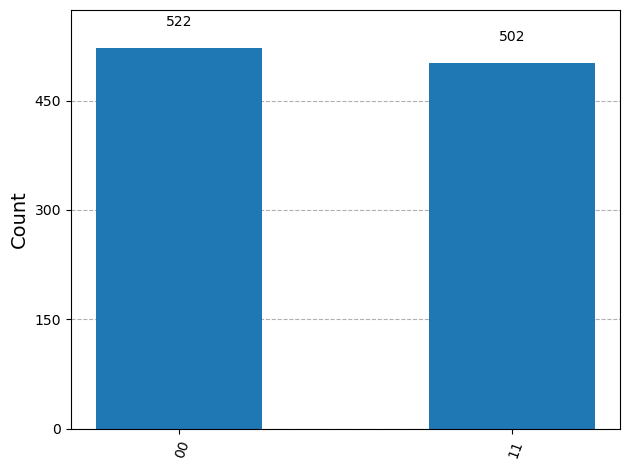

In [8]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# TODO
circ.measure_all()
sim = AerSimulator()

job = sim.run(circ, shots=1024)
result = job.result()
counts = result.get_counts()

plt.close("all")
fig = plot_histogram(counts)
plt.show()

# Exercise 6

(a) Write a function which is able to return a circuit representing a balanced and a constant oracle.

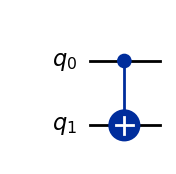

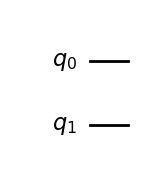

In [20]:
# simple implementation which is only able to return one balanced and one constant oracle
def create_oracle(balanced='True'):
    circ = QuantumCircuit(2)
    
    if balanced:
        # TODO: implementar oracle balanceado
        circ.cx(0,1)
    
    return circ
    
create_oracle().draw('mpl')
plt.show()

create_oracle(False).draw('mpl')
plt.show()

In [21]:
import qiskit.quantum_info as qi


# function to print the oracle matrices in a nicer way
def print_bin_matrix(matrix):
    for row in matrix.data:
        for element in row:
            print(int(element), end=' ')
        print('\n', end='')
    print('\n', end='')


# check if the oracle works by taking a look at the matrix representation of the circuit
# the matrices may look different than the ones on lecture 5 slide 10, since the ordering of qubits in Qiskit is reversed
print_bin_matrix(qi.Operator(create_oracle(True)))
print_bin_matrix(qi.Operator(create_oracle(False)))

1 0 0 0 
0 0 0 1 
0 0 1 0 
0 1 0 0 

1 0 0 0 
0 1 0 0 
0 0 1 0 
0 0 0 1 



/tmp/ipykernel_40685/2465051928.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  print(int(element), end=' ')


(b) Implement the remaining algorithm and print the circuit representation.

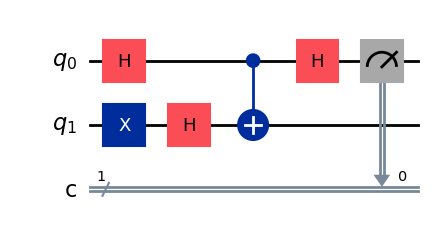

In [26]:
def create_deutsch_circuit(unary_function):
    circ = QuantumCircuit(2,1)
    circ.x(1)
    circ.h(0)
    circ.h(1)
    circ = circ.compose(create_oracle(unary_function))
    circ.h(0)
    circ.measure(0, 0)
    return circ


# TODO: print one example
create_deutsch_circuit(True).draw('mpl')
plt.show()

(c) Simulate the circuit for the balanced and constant case. $\lvert 10\rangle$ means constant case and $\lvert 11\rangle$ means balanced case. Note that the order of qubits is reversed compared to the lecture slides.

In [ ]:
# TODO: constant 

In [ ]:
# TODO: balanced

# Exercise 7

(a) Extend the function from the previous exercise to make it produce n-ary balanced or constant oracles.

In [ ]:
from sympy.matrices import Matrix, eye
from qiskit.quantum_info.operators import Operator


# simple implementation which is only able to return one balanced and one constant oracle
def create_simple_mult_oracle(is_balanced, n=1):
    # TODO


# Harder solution!
# create a unitary matrix which represents the oracle
def create_oracle_matrix(lookup_table):
    # TODO


# create a circuit from the unitary matrix
def create_mult_oracle(lookup_table, n=1):
    # TODO

(b) Implement the remaining algorithm and print the circuit representation for $n=4$.

In [ ]:
import math


def create_deutsch_josza_circuit(lookup_table):
    # TODO
    return deutsch

In [ ]:
# print one example for n=4
create_deutsch_josza_circuit([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]).draw(initial_state=True, output='mpl')

(c) Simulate the circuit for $n=4$ and the balanced and constant case. Measuring $\lvert10000\rangle$ means constant, every other measurement means balanced.

In [ ]:
# TODO: balanced


In [ ]:
# TODO: constant


(d) What happens if the oracle is neither constant nor balanced? Answer:

In [ ]:
# neither constant nor balanced
# TODO (if you implemented the complex version)

# Exercise 8

Run the Deutsch-Josza algorithm on a real device.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import # TODO
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


# load API token (needs to be stored first)
#service = QiskitRuntimeService(channel="ibm_quantum")

# Real device
#device = service.least_busy(operational=True, simulator=False)  

# Fake device (Emulation of real device)
device = # TODO

# TODO


In [ ]:
# TODO: Run constant case


(c) Interpret the results, what is the difference to the result of the noise-free simulation?

In [ ]:
# Hint: Take a look at the gates composing the circuits